# HPD 4 — Sistema RAG sobre datos mixtos con evaluación

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/evaluables/hpd4-rag-mixto.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> **Duración:** 4h
>
> **Competencias:** [CE-4](../index.qmd#competencias-específicas)

> **Objetivos**
>
> - Construir un pipeline RAG que procese datos no estructurados (PDF) y
>   estructurados (SQL)
> - Implementar un re-ranker con cross-encoder y medir su impacto
> - Crear un dataset de preguntas anotadas manualmente (ground truth)
> - Evaluar la calidad del sistema con RAGAS
> - Iterar sobre componentes individuales para mejorar métricas
>
> ## Materiales
>
> - Librerías: `langchain`, `langchain-community`, `chromadb`,
>   `sentence-transformers`, `ragas`, `datasets`, `fpdf2`, `pandas`,
>   `matplotlib`
> - Modelo embeddings: `intfloat/e5-small-v2`
> - Cross-encoder: `cross-encoder/ms-marco-MiniLM-L-6-v2`
> - Corpus mixto: 3 PDFs de informes trimestrales + 1 tabla SQLite de
>   productos (generados inline)
> - LLM: API Llamus US (`https://llamus.cs.us.es/api/v1`, modelo
>   `gemma4:e2b-mlx`) o local (Ollama)
>
> ## Pipeline
>
> 1.  **Corpus mixto:** generar PDFs de informes + tabla SQLite de
>     productos
> 2.  **Indexación dual:** indexar PDFs y SQL en Chroma
> 3.  **Retrievers:** implementar y combinar retrievers de ambas fuentes
> 4.  **Re-ranker:** añadir cross-encoder y medir la mejora
> 5.  **RAG:** construir el pipeline completo con LLM
> 6.  **Evaluación:** crear ground truth y evaluar con RAGAS
> 7.  **Iteración:** ajustar componentes y comparar versiones

> **¿Por qué necesitas esto?**
>
> Imagina que tu empresa tiene informes trimestrales en PDF con análisis
> narrativo de ventas, y una base de datos SQL con precios, márgenes y
> stock de cada producto. Tu jefe pregunta: *“¿Qué productos del informe
> Q2 tienen margen inferior al 20%?”* Un buscador por palabras clave no
> entiende la pregunta. Un RAG sobre datos mixtos sí: busca en los PDFs
> qué productos se mencionan en Q2, cruza con la tabla SQL para filtrar
> por margen, y genera una respuesta fundamentada en ambas fuentes.
>
> En este taller construyes ese sistema completo. Y al final lo evalúas
> con RAGAS para saber **objetivamente** si funciona bien, no solo “a
> ojo”.

In [1]:
!pip install -q chromadb sentence-transformers langchain langchain-community langchain-text-splitters pypdf ragas datasets fpdf2 pandas matplotlib scikit-learn python-dotenv flashrank

In [2]:
import os, tempfile, shutil, sqlite3
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from langchain_openai import ChatOpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env con:\n    LLM_API_KEY=tu_api_key")
else:
    llm = ChatOpenAI(model="gemma4:e2b-mlx", base_url=LLM_URL, api_key=LLM_KEY, temperature=0)
    print("✅ LLM configurado (gemma4:e2b-mlx).")

✅ LLM configurado (gemma4:e2b-mlx).

In [4]:
from sentence_transformers import SentenceTransformer
import chromadb

MODEL_NAME = "intfloat/e5-small-v2"
model = SentenceTransformer(MODEL_NAME)
client = chromadb.EphemeralClient()

BASE_DIR = tempfile.mkdtemp()
CORPUS_DIR = os.path.join(BASE_DIR, "corpus")
os.makedirs(CORPUS_DIR)

print(f"Modelo: {MODEL_NAME} ({model.get_embedding_dimension()} dims)")
print(f"Corpus temporal: {CORPUS_DIR}")

Modelo: intfloat/e5-small-v2 (384 dims)
Corpus temporal: /var/folders/bd/_fc1rf8x6jv7w5hxv_rlkdbr0000gn/T/tmp5g0beo8y/corpus

------------------------------------------------------------------------

# Parte 1 — Corpus mixto: PDFs + SQL

Creamos un corpus corporativo con dos tipos de datos: - **3 PDFs** de
informes trimestrales de ventas (generados con `fpdf2`) - **1 tabla
SQLite** de productos con precios, márgenes y stock

## 1.1 Generar los PDFs de informes trimestrales

In [5]:
from fpdf import FPDF

class PDF(FPDF):
    pass

def crear_pdf(nombre, titulo, contenido):
    pdf = PDF()
    pdf.add_page()
    pdf.set_font("Helvetica", "B", 16)
    pdf.cell(0, 10, titulo, new_x="LMARGIN", new_y="NEXT")
    pdf.ln(5)
    pdf.set_font("Helvetica", "", 11)
    pdf.multi_cell(0, 6, contenido)
    pdf.output(os.path.join(CORPUS_DIR, nombre))

informes = {
    "informe_q1_2026.pdf": (
        "Informe de Ventas - Primer Trimestre 2026",
        "El primer trimestre de 2026 ha mostrado un crecimiento sólido del 12% "
        "respecto al mismo periodo del año anterior. Los ingresos totales alcanzaron "
        "los 2.4 millones de euros, impulsados principalmente por la categoría de "
        "Electrónica de consumo, que creció un 18% gracias al lanzamiento del "
        "nuevo modelo de auriculares inalámbricos NovaBuds Pro. La tabla de "
        "productos refleja un margen medio del 35% en esta categoría, con el "
        "Monitor 4K liderando en rentabilidad con un margen del 42%.\n\n"
        "En la categoría de Hogar y Oficina, los ingresos se mantuvieron estables "
        "con 680.000 euros, aunque la Silla Ergonómica Pro experimentó una caída "
        "del 5% en ventas respecto al Q4 2025. El stock de este producto se sitúa "
        "en 45 unidades, por encima del umbral de reposición. La Lámpara LED Smart "
        "y el Purificador de Aire Compacto compensaron la bajada con crecimientos "
        "del 8% y 12% respectivamente.\n\n"
        "El departamento de Deportes y Aire Libre tuvo un inicio de año prometedor "
        "con la Bicicleta Eléctrica Urbana como producto estrella, generando 340.000 "
        "euros en pedidos. La tienda de campaña Ultralight mostró buena tracción en "
        "el canal online, con un 40% de las ventas a través de la web. Sin embargo, "
        "el margen de esta categoría (22% medio) está por debajo del objetivo "
        "corporativo del 25%, lo que requerirá revisar la política de descuentos."
    ),
    "informe_q2_2026.pdf": (
        "Informe de Ventas - Segundo Trimestre 2026",
        "El segundo trimestre de 2026 consolidó la tendencia alcista con ingresos "
        "de 2.8 millones de euros, un 16% más que el Q2 2025. La categoría de "
        "Electrónica de consumo siguió liderando con el Teclado Mecánico RGB como "
        "novedad del trimestre, alcanzando 4.200 unidades vendidas en sus primeras "
        "8 semanas. El margen del 28% en este producto es inferior al del Monitor 4K, "
        "pero su alto volumen compensa la diferencia.\n\n"
        "Hogar y Oficina experimentó un repunte gracias a la campaña de primavera, "
        "con la Silla Ergonómica Pro recuperando terreno tras los descuentos "
        "estratégicos del Q1. El stock actual de 32 unidades indica que la demanda "
        "se ha normalizado. La Lámpara LED Smart duplicó sus ventas respecto al Q1 "
        "tras aparecer en tres publicaciones de decoración. El Escritorio Ajustable "
        "se posiciona como el producto de mayor ticket medio (299 euros) dentro de "
        "esta categoría.\n\n"
        "En Deportes y Aire Libre, el buen tiempo impulsó las ventas de la Tienda "
        "de Campaña Ultralight (620 unidades, +35% vs Q2 2025) y las Zapatillas "
        "Trail Running. La Bicicleta Eléctrica Urbana mantuvo el ritmo con 280.000 "
        "euros en ingresos. El margen medio de la categoría mejoró ligeramente hasta "
        "el 23.5%, acercándose al objetivo corporativo."
    ),
    "informe_q3_2026.pdf": (
        "Informe de Ventas - Tercer Trimestre 2026 y Previsión Anual",
        "El tercer trimestre de 2026 cerró con ingresos de 3.1 millones de euros, "
        "el mayor trimestre del año. La previsión anual apunta a superar los 11 "
        "millones de euros, un 14% por encima del objetivo inicial. La categoría de "
        "Electrónica de consumo representa ya el 42% de los ingresos totales, con "
        "el Monitor 4K y los NovaBuds Pro como productos ancla.\n\n"
        "Hogar y Oficina alcanzó su techo histórico con 820.000 euros en el Q3, "
        "impulsado por la vuelta al trabajo presencial y la renovación de equipamiento "
        "en oficinas. El Escritorio Ajustable fue el producto más rentable del "
        "trimestre con un margen del 45%. La Lámpara LED Smart se acerca al límite "
        "de stock (quedan 15 unidades) y se recomienda un pedido urgente de "
        "reposición antes del Black Friday.\n\n"
        "Deportes y Aire Libre registró 580.000 euros, con las Zapatillas Trail "
        "Running como producto revelación (+45% respecto al Q2). La Tienda de Campaña "
        "Ultralight agotó existencias en septiembre (stock actual: 0 unidades) y "
        "hay una lista de espera de 80 clientes. La Bicicleta Eléctrica Urbana "
        "ralentizó su crecimiento por problemas en la cadena de suministro de "
        "baterías, afectando también al margen (bajó del 22% al 19%).\n\n"
        "Riesgos para el Q4: rotura de stock en Tienda de Campaña, dependencia de "
        "un único proveedor de baterías para la bicicleta eléctrica, y posible "
        "erosión de márgenes en Electrónica por la guerra de precios en el Black Friday."
    ),
}

for nombre, (titulo, contenido) in informes.items():
    crear_pdf(nombre, titulo, contenido)

print(f"✅ {len(informes)} PDFs generados en {CORPUS_DIR}")
for nombre in informes:
    size_kb = os.path.getsize(os.path.join(CORPUS_DIR, nombre)) / 1024
    print(f"   {nombre}: {size_kb:.0f} KB")

✅ 3 PDFs generados en /var/folders/bd/_fc1rf8x6jv7w5hxv_rlkdbr0000gn/T/tmp5g0beo8y/corpus
   informe_q1_2026.pdf: 2 KB
   informe_q2_2026.pdf: 2 KB
   informe_q3_2026.pdf: 2 KB

## 1.2 Crear tabla SQLite de productos

In [6]:
DB_PATH = os.path.join(tempfile.mkdtemp(), "productos.db")
conn = sqlite3.connect(DB_PATH)

conn.execute("""
    CREATE TABLE productos (
        id INTEGER PRIMARY KEY,
        nombre TEXT NOT NULL,
        categoria TEXT NOT NULL,
        precio REAL NOT NULL,
        margen_pct REAL NOT NULL,
        stock INTEGER NOT NULL
    )
""")

productos_data = [
    (1,  "Monitor 4K 27\"",           "Electrónica de consumo", 349.00, 42, 120),
    (2,  "NovaBuds Pro",              "Electrónica de consumo", 89.00,  35, 250),
    (3,  "Teclado Mecánico RGB",      "Electrónica de consumo", 79.00,  28, 180),
    (4,  "Webcam 1080p Pro",          "Electrónica de consumo", 59.00,  30, 90),
    (5,  "Silla Ergonómica Pro",      "Hogar y Oficina",       249.00, 38, 32),
    (6,  "Escritorio Ajustable",      "Hogar y Oficina",       299.00, 45, 18),
    (7,  "Lámpara LED Smart",         "Hogar y Oficina",       49.00,  50, 15),
    (8,  "Purificador de Aire Compacto","Hogar y Oficina",     129.00, 32, 55),
    (9,  "Bicicleta Eléctrica Urbana","Deportes y Aire Libre", 899.00, 19, 25),
    (10, "Tienda de Campaña Ultralight","Deportes y Aire Libre",199.00, 24, 0),
    (11, "Zapatillas Trail Running",  "Deportes y Aire Libre", 89.00,  26, 140),
    (12, "Mochila Hidratación 10L",   "Deportes y Aire Libre", 45.00,  35, 200),
]

conn.executemany(
    "INSERT INTO productos VALUES (?, ?, ?, ?, ?, ?)",
    productos_data
)
conn.commit()

print(f"✅ {len(productos_data)} productos en SQLite")
print(f"\n--- Productos por categoría ---")
for row in conn.execute(
    "SELECT categoria, COUNT(*), ROUND(AVG(margen_pct), 1) FROM productos GROUP BY categoria"
):
    print(f"  {row[0]:30s} | {row[1]} productos | margen medio {row[2]}%")

print(f"\n--- Productos con stock crítico (< 20 unidades) ---")
for row in conn.execute(
    "SELECT nombre, stock FROM productos WHERE stock < 20 ORDER BY stock"
):
    print(f"  {row[0]:35s} | stock: {row[1]}")

✅ 12 productos en SQLite

--- Productos por categoría ---
  Deportes y Aire Libre          | 4 productos | margen medio 26.0%
  Electrónica de consumo         | 4 productos | margen medio 33.8%
  Hogar y Oficina                | 4 productos | margen medio 41.3%

--- Productos con stock crítico (< 20 unidades) ---
  Tienda de Campaña Ultralight        | stock: 0
  Lámpara LED Smart                   | stock: 15
  Escritorio Ajustable                | stock: 18

In [7]:
# Convertir cada fila de productos a texto (mismo patrón que HPD 1 tabular)
df_productos = pd.DataFrame(
    productos_data,
    columns=["id", "nombre", "categoria", "precio", "margen_pct", "stock"]
)

df_productos["texto"] = df_productos.apply(
    lambda r: f"Producto: {r['nombre']}. Categoría: {r['categoria']}. "
              f"Precio: {r['precio']}€. Margen: {r['margen_pct']}%. Stock: {r['stock']} unidades.",
    axis=1
)

print("Filas convertidas a texto (muestra):")
for t in df_productos["texto"].head(4):
    print(f"  → {t}")

Filas convertidas a texto (muestra):
  → Producto: Monitor 4K 27". Categoría: Electrónica de consumo. Precio: 349.0€. Margen: 42%. Stock: 120 unidades.
  → Producto: NovaBuds Pro. Categoría: Electrónica de consumo. Precio: 89.0€. Margen: 35%. Stock: 250 unidades.
  → Producto: Teclado Mecánico RGB. Categoría: Electrónica de consumo. Precio: 79.0€. Margen: 28%. Stock: 180 unidades.
  → Producto: Webcam 1080p Pro. Categoría: Electrónica de consumo. Precio: 59.0€. Margen: 30%. Stock: 90 unidades.

------------------------------------------------------------------------

# Parte 2 — Indexación dual en Chroma

Indexamos ambas fuentes en collections separadas. Ya sabes hacer esto
del HPD 1.

## 2.1 Cargar y trocear los PDFs

In [8]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_SIZE = 400
CHUNK_OVERLAP = 60

# ─── COMPLETAR: cargar y trocear PDFs ───
def cargar_y_trocear_pdfs(dir_path, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP):
    """
    Carga todos los PDFs de un directorio y los divide en chunks.

    Returns:
        list[Document]: Chunks con page_content y metadata.
    """
    documentos = []
    for filename in sorted(os.listdir(dir_path)):
        if not filename.endswith(".pdf"):
            continue
        # TODO: Crear PyPDFLoader con la ruta del archivo
        # TODO: loader.load() y extender la lista
        pass  # ← completar

    # TODO: Crear RecursiveCharacterTextSplitter con chunk_size, chunk_overlap
    # TODO: splitter.split_documents(documentos)
    return []  # ← completar

chunks_pdf = cargar_y_trocear_pdfs(CORPUS_DIR)
print(f"Chunks PDF generados: {len(chunks_pdf)}")
if chunks_pdf:
    for i, c in enumerate(chunks_pdf):
        print(f"  [{i}] {os.path.basename(c.metadata['source'])}: {len(c.page_content)} chars")

Chunks PDF generados: 0

## 2.2 Indexar PDFs en Chroma

In [9]:
collection_pdf = client.get_or_create_collection(
    name="hpd4_pdfs",
    metadata={"hnsw:space": "cosine"}
)

# ─── COMPLETAR: indexar los chunks de PDFs ───
# Por cada chunk en chunks_pdf:
#   1. model.encode(chunk.page_content)
#   2. collection_pdf.add() con id único, embedding, documento y metadata
# Pista: mismo patrón que en HPD 1, sección 1.4

if chunks_pdf:
    print(f"✅ Indexación completada: {collection_pdf.count()} vectores")
else:
    print("⚠️  Completa cargar_y_trocear_pdfs() primero.")

⚠️  Completa cargar_y_trocear_pdfs() primero.

## 2.3 Indexar productos SQL en Chroma

In [10]:
collection_sql = client.get_or_create_collection(
    name="hpd4_productos",
    metadata={"hnsw:space": "cosine"}
)

# ─── COMPLETAR: indexar los productos ───
# Por cada fila de df_productos:
#   1. model.encode(df_productos["texto"][i])
#   2. collection_sql.add() con id, embedding, documento y metadata (nombre, categoria)
# Pista: mismo patrón que HPD 1, sección 1.6 (tabular)

print(f"✅ Indexación completada: {collection_sql.count()} vectores")

✅ Indexación completada: 0 vectores

------------------------------------------------------------------------

# Parte 3 — Retrievers

Implementamos un retriever para cada fuente y los combinamos. El
retriever busca los k chunks más similares a la pregunta del usuario.

## 3.1 Función de búsqueda unificada

In [11]:
def buscar_en_coleccion(collection, query, k=3):
    """
    Busca los k chunks más similares en una colección de Chroma.

    Returns:
        list[dict]: Lista de resultados con 'texto', 'distancia' y 'metadata'.
    """
    query_emb = model.encode(query).tolist()
    res = collection.query(query_embeddings=[query_emb], n_results=k)

    resultados = []
    if res["ids"] and res["ids"][0]:
        for i in range(len(res["ids"][0])):
            resultados.append({
                "id": res["ids"][0][i],
                "texto": res["documents"][0][i],
                "distancia": res["distances"][0][i],
                "metadata": res["metadatas"][0][i] if res["metadatas"] else {},
            })
    return resultados

# ─── COMPLETAR: implementa buscar_combinada ───
def buscar_combinada(query, k_pdf=3, k_sql=3):
    """
    Busca simultáneamente en PDFs y en SQL y combina los resultados.

    Returns:
        list[dict]: Resultados combinados, ordenados por distancia.
    """
    # TODO: Llamar a buscar_en_coleccion para cada collection
    # TODO: Combinar resultados en una lista
    # TODO: Ordenar por distancia (menor = más relevante)
    return []  # ← completar

# Probar
resultados = buscar_combinada("¿Qué productos tienen problemas de stock?", k_pdf=2, k_sql=2)
print(f"Resultados combinados: {len(resultados)}")
for r in resultados:
    print(f"  [{r['distancia']:.4f}] {r['texto'][:100]}...")

Resultados combinados: 0

------------------------------------------------------------------------

# Parte 4 — Re-ranker con cross-encoder

El retriever semántico (embeddings) es rápido pero poco preciso con
matices. El re-ranker con cross-encoder relee cada chunk junto a la
query y asigna una puntuación de relevancia más fina. Es más lento pero
más preciso. Lo aplicamos **después** del retriever para reordenar los
top-K resultados.

In [12]:
from langchain_community.document_compressors import FlashrankRerank

reranker = FlashrankRerank(top_n=3, model="ms-marco-TinyBERT-L-2-v2")

def rerank(query, resultados, top_n=3):
    """Reordena los resultados usando FlashrankRerank.

    Args:
        query: pregunta del usuario (str).
        resultados: list[dict] con claves 'texto', 'distancia', 'metadata'.
        top_n: número de resultados a devolver.

    Returns:
        list[dict] con los mismos campos, reordenados por relevancia.
    """
    from langchain_core.documents import Document
    docs = [Document(page_content=r["texto"], metadata=r["metadata"]) for r in resultados]
    reranked = reranker.compress_documents(docs, query)
    return [r for r in resultados if r["texto"] in (d.page_content for d in reranked)][:top_n]

print(f"✅ Re-ranker configurado (FlashrankRerank, top_n={reranker.top_n}).")

✅ Re-ranker configurado (FlashrankRerank, top_n=3).

In [13]:
# Probar el re-ranker: comparar antes vs. después
query_test = "¿Qué productos de electrónica tienen mejor margen?"
resultados_brutos = buscar_combinada(query_test, k_pdf=3, k_sql=3)

print("ANTES del re-ranker (orden por embedding):")
for r in resultados_brutos[:3]:
    print(f"  [{r['distancia']:.4f}] {r['texto'][:80]}...")

# TODO: Descomenta cuando hayas implementado rerank()
# resultados_rerank = rerank(query_test, resultados_brutos, top_n=3)
# print("\nDESPUÉS del re-ranker (orden por cross-encoder):")
# for r in resultados_rerank[:3]:
#     print(f"  {r['texto'][:80]}...")

print("\n⚠️  Implementa rerank() y compara los órdenes antes/después.")

ANTES del re-ranker (orden por embedding):

⚠️  Implementa rerank() y compara los órdenes antes/después.

> **¿Por qué dos pasos? Retriever + Re-ranker**
>
> El retriever semántico (embeddings) revisa **todos** los documentos en
> milisegundos y selecciona los K más prometedores. El re-ranker
> (cross-encoder) relee **solo esos K** con más profundidad. Sin
> re-ranker: rápido pero impreciso. Sin retriever: lento (no puedes
> pasar 1000 chunks por un cross-encoder). La combinación da lo mejor de
> ambos mundos.

------------------------------------------------------------------------

# Parte 5 — Pipeline RAG completo

Unimos todos los componentes: búsqueda combinada → re-ranker → prompt
con contexto → LLM.

In [14]:
# ─── COMPLETAR: implementa el prompt del RAG ───
SYSTEM_PROMPT_RAG = """
Eres un analista de negocio que responde preguntas basándose EXCLUSIVAMENTE
en los fragmentos de documentos proporcionados como contexto.

Reglas:
- Si el contexto contiene la respuesta, responde de forma concisa y cita la fuente.
- Si el contexto NO contiene información suficiente, di "No tengo datos suficientes
  para responder a esta pregunta" y no inventes nada.
- Responde SIEMPRE en español.
"""

# ─── COMPLETAR: implementa la función rag ───
def rag(pregunta, k_pdf=3, k_sql=3, usar_reranker=True):
    """
    Pipeline RAG completo: recupera contexto, reordena, genera respuesta.

    Args:
        pregunta: consulta en lenguaje natural.
        k_pdf: número de chunks a recuperar de PDFs.
        k_sql: número de chunks a recuperar de SQL.
        usar_reranker: si True, aplica re-ranker a los resultados combinados.

    Returns:
        dict con 'respuesta', 'fuentes' (lista de textos usados) y 'pregunta'.
    """
    if not LLM_KEY:
        return {"respuesta": "⚠️ Configura LLM_API_KEY en .env", "fuentes": [], "pregunta": pregunta}

    # TODO: 1. Buscar en ambas fuentes con buscar_combinada()
    # TODO: 2. Si usar_reranker, aplicar rerank()
    # TODO: 3. Construir contexto uniendo los textos de los chunks top-3
    # TODO: 4. Llamar al LLM con el prompt + contexto + pregunta
    # TODO: 5. Devolver dict con respuesta, fuentes y pregunta

    return {"respuesta": "⚠️ Implementa rag()", "fuentes": [], "pregunta": pregunta}

print("✅ Pipeline RAG definido.")

✅ Pipeline RAG definido.

In [15]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env.")
else:
    pregunta = "¿Qué productos de Hogar y Oficina tienen problemas de stock?"
    print(f"PREGUNTA: {pregunta}\n")
    # resultado = rag(pregunta)
    # print(f"RESPUESTA: {resultado['respuesta']}")
    # print(f"\nFuentes usadas ({len(resultado['fuentes'])}):")
    # for i, fuente in enumerate(resultado['fuentes']):
    #     print(f"  [{i+1}] {fuente[:100]}...")
    print("⚠️  Descomenta cuando hayas implementado rag().")

PREGUNTA: ¿Qué productos de Hogar y Oficina tienen problemas de stock?

⚠️  Descomenta cuando hayas implementado rag().

------------------------------------------------------------------------

# Parte 6 — Dataset de evaluación y RAGAS

RAGAS evalúa automáticamente la calidad del RAG sin necesidad de
respuestas de referencia. Mide 3 dimensiones:

- **Faithfulness:** ¿la respuesta es fiel a los chunks recuperados o se
  inventa cosas?
- **Answer Relevancy:** ¿la respuesta es pertinente a la pregunta?
- **Context Precision:** ¿los chunks recuperados son relevantes para la
  pregunta?

## 6.1 Crear dataset de preguntas anotadas

In [16]:
# ─── COMPLETAR: crea tu dataset de evaluación ───
# Cada pregunta necesita:
#   - question: la pregunta en lenguaje natural
#   - answer: la respuesta generada por tu RAG (la obtienes ejecutando rag())
#   - contexts: lista de textos de los chunks recuperados
#   - ground_truth: respuesta esperada (manual, para comparar)

preguntas_eval = [
    "¿Qué productos de Electrónica de consumo tienen un margen superior al 30%?",
    "¿Cuál es la situación actual del stock de la Tienda de Campaña Ultralight?",
    "¿Qué producto tuvo el mayor crecimiento en el Q2 según los informes?",
    "¿Qué riesgos se mencionan para el Q4?",
    "¿Cuál es el margen medio de la categoría Deportes y Aire Libre?",
    "¿Qué productos tienen un precio superior a 200 euros y stock inferior a 30 unidades?",
    "¿Cómo evolucionaron las ventas de la Silla Ergonómica Pro entre Q1 y Q2?",
    # TODO: Añade al menos 3 preguntas más (mínimo 10 en total)
]

# Generar respuestas con el RAG para cada pregunta
dataset_eval = []
for pregunta in preguntas_eval:
    # TODO: Llamar a rag(pregunta)
    # TODO: Guardar question, answer, contexts, ground_truth
    pass  # ← completar

print(f"Dataset de evaluación: {len(dataset_eval)} preguntas")

Dataset de evaluación: 0 preguntas

## 6.2 Evaluar con RAGAS

In [17]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from datasets import Dataset

# ─── COMPLETAR: evaluar con RAGAS ───
# TODO: Convertir dataset_eval a Dataset de Hugging Face
#   dataset_hf = Dataset.from_dict({
#       "question": [...],
#       "answer": [...],
#       "contexts": [...],
#       "ground_truth": [...],
#   })
# TODO: Ejecutar evaluate(dataset_hf, metrics=[faithfulness, answer_relevancy, context_precision])
# TODO: Convertir resultados a DataFrame y mostrarlo

# result = evaluate(...)
# df_result = result.to_pandas()
# print(df_result[["faithfulness", "answer_relevancy", "context_precision"]])

print("⚠️  Completa el dataset y la evaluación con RAGAS.")

⚠️  Completa el dataset y la evaluación con RAGAS.

------------------------------------------------------------------------

# Parte 7 — Iteración y mejora

La evaluación no es un trámite: es una herramienta para **mejorar**.
Vamos a modificar componentes y medir el impacto.

In [18]:
# ─── COMPLETAR: tabla de iteraciones ───
# Ejecuta tu RAG con al menos 2 configuraciones distintas y compara:

# Versión 1: tu configuración base
# Versión 2: cambia UN componente (chunk_size, k_pdf/k_sql, top_n del re-ranker, prompt)

# Para cada versión, anota:
#   - Qué cambiaste
#   - Faithfulness medio
#   - Answer Relevancy medio
#   - Context Precision medio
#   - ¿Mejoró o empeoró? ¿Por qué crees que pasó?

iteraciones = [
    # {"version": "Base", "cambio": "CHUNK_SIZE=400, k=3, top_n=3",
    #  "faithfulness": 0.0, "answer_relevancy": 0.0, "context_precision": 0.0},
    # {"version": "Chunk 600", "cambio": "CHUNK_SIZE=600",
    #  "faithfulness": 0.0, "answer_relevancy": 0.0, "context_precision": 0.0},
]
print("⚠️  Completa al menos 2 versiones comparadas.")

⚠️  Completa al menos 2 versiones comparadas.

------------------------------------------------------------------------

# Batería de pruebas

5 preguntas de dificultad creciente para validar tu pipeline completo.

In [19]:
preguntas_prueba = [
    # Nivel 1: respuesta en un solo tipo de fuente
    "¿Cuál es el margen del Monitor 4K?",

    # Nivel 2: respuesta en la otra fuente
    "¿Qué informe trimestral menciona problemas con la cadena de suministro?",

    # Nivel 3: cruza ambas fuentes
    "¿Qué productos mencionados en el informe Q2 tienen un stock inferior a 40 unidades?",

    # Nivel 4: requiere razonamiento
    "Basándote en los informes y los datos de producto, ¿qué categoría tiene más riesgo de rotura de stock en el Q4?",

    # Nivel 5: análisis complejo multi-fuente
    "Compara la evolución de la categoría Deportes a lo largo de los 3 trimestres, teniendo en cuenta tanto los informes narrativos como los márgenes actuales de los productos.",
]

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env.")
else:
    for i, pregunta in enumerate(preguntas_prueba, 1):
        print(f"\n{'='*70}")
        print(f"PREGUNTA {i}: {pregunta}")
        print('='*70)
        try:
            # res = rag(pregunta)
            # print(f"\nRESPUESTA: {res['respuesta']}")
            print("⚠️  Descomenta cuando hayas implementado rag().")
        except Exception as e:
            print(f"ERROR: {e}")


PREGUNTA 1: ¿Cuál es el margen del Monitor 4K?
⚠️  Descomenta cuando hayas implementado rag().

PREGUNTA 2: ¿Qué informe trimestral menciona problemas con la cadena de suministro?
⚠️  Descomenta cuando hayas implementado rag().

PREGUNTA 3: ¿Qué productos mencionados en el informe Q2 tienen un stock inferior a 40 unidades?
⚠️  Descomenta cuando hayas implementado rag().

PREGUNTA 4: Basándote en los informes y los datos de producto, ¿qué categoría tiene más riesgo de rotura de stock en el Q4?
⚠️  Descomenta cuando hayas implementado rag().

PREGUNTA 5: Compara la evolución de la categoría Deportes a lo largo de los 3 trimestres, teniendo en cuenta tanto los informes narrativos como los márgenes actuales de los productos.
⚠️  Descomenta cuando hayas implementado rag().

## Tabla de evaluación

    ┌────┬──────────────────────────────────────────┬─────────────────┬──────────┬─────────────────────────┐
    │  # │ Pregunta                                 │ Fuente principal│ ¿Correcto?│ Observaciones           │
    ├────┼──────────────────────────────────────────┼─────────────────┼──────────┼─────────────────────────┤
    │  1 │ Margen Monitor 4K                        │                 │   / 5    │                         │
    │  2 │ Informe cadena suministro                │                 │   / 5    │                         │
    │  3 │ Productos Q2 + stock < 40                │                 │   / 5    │                         │
    │  4 │ Categoría con más riesgo Q4              │                 │   / 5    │                         │
    │  5 │ Evolución Deportes en 3 trimestres       │                 │   / 5    │                         │
    └────┴──────────────────────────────────────────┴─────────────────┴──────────┴─────────────────────────┘

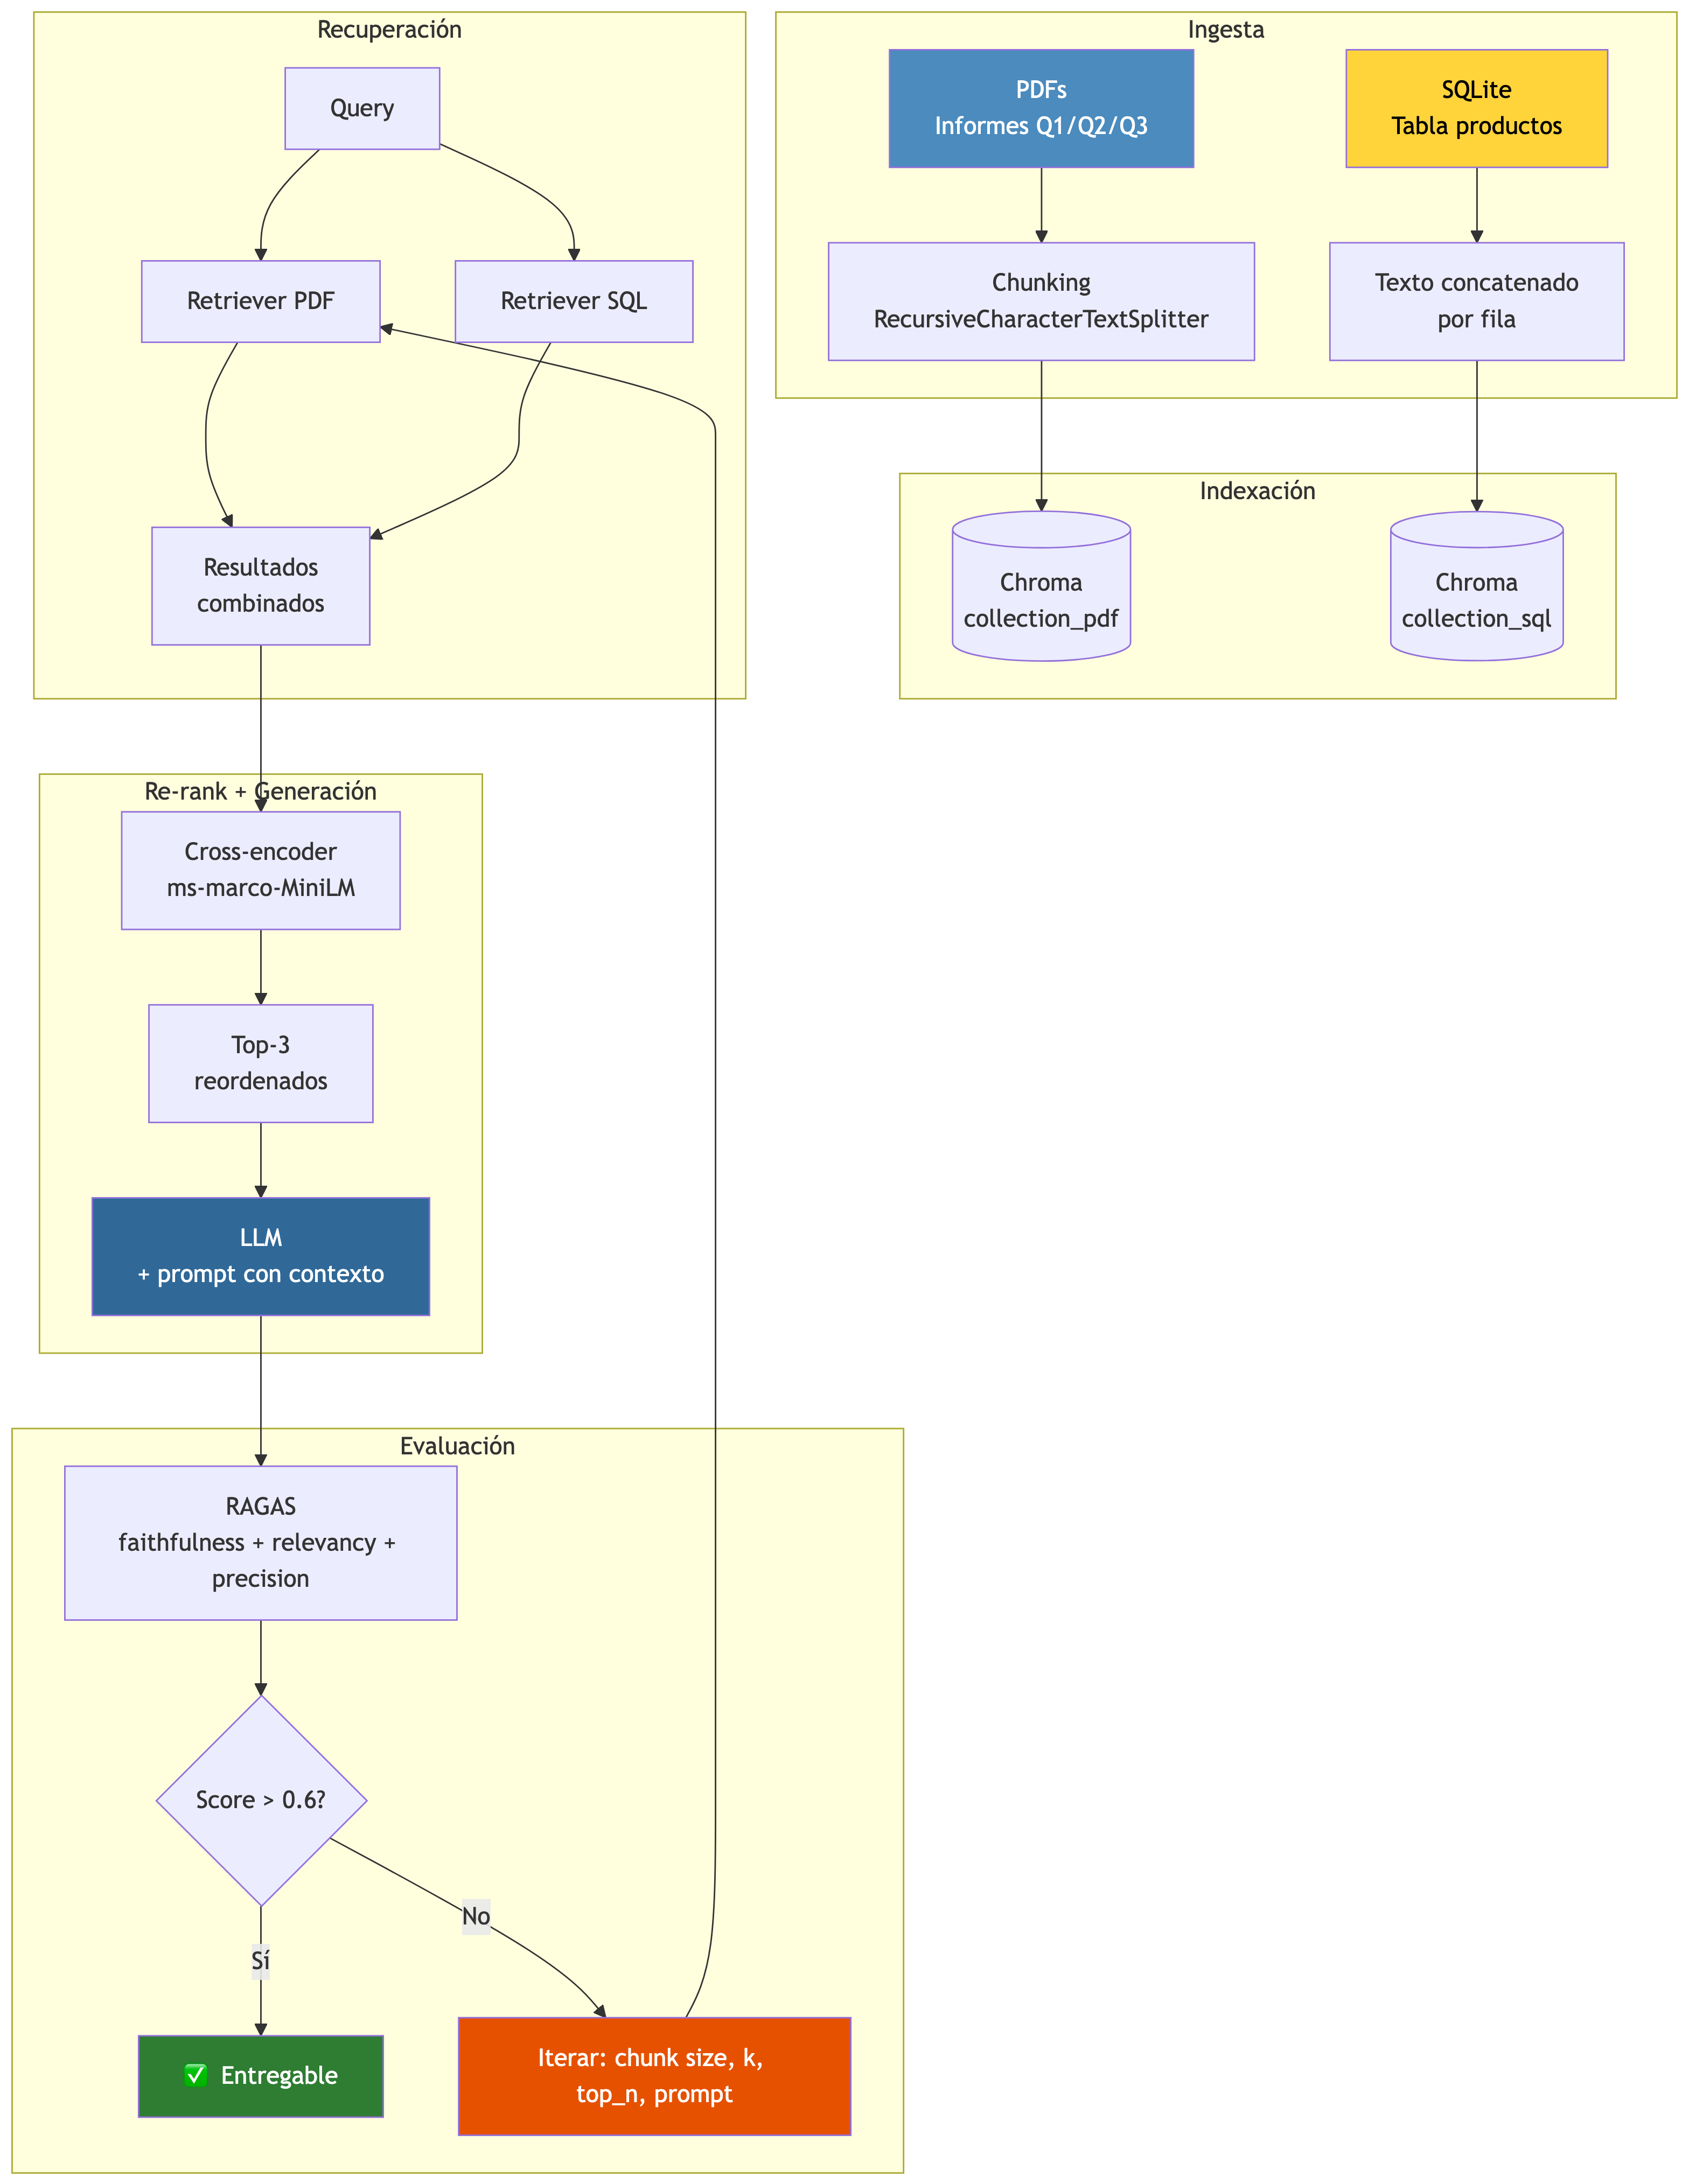

------------------------------------------------------------------------

# Ejercicios

> **Para afianzar lo aprendido (~45 min)**
>
> Estos ejercicios no se entregan, pero te preparan para las entregas
> HPD y el proyecto integrador.
>
> ------------------------------------------------------------------------
>
> **A1 — Experimenta con el chunk size (~15 min)**
>
> Ejecuta el pipeline con `CHUNK_SIZE = 200, 600` (mantén overlap al
> 15%). Para cada uno, mide las 3 métricas de RAGAS. ¿Qué tamaño
> funciona mejor para este corpus? ¿Por qué?
>
> > **Note**
> >
> > **Objetivo:** interiorizar que el chunk size es el hiperparámetro
> > más impactante en RAG.
>
> ------------------------------------------------------------------------
>
> **A2 — Mide el impacto del re-ranker (~15 min)**
>
> Ejecuta el RAG con `usar_reranker=True` y `usar_reranker=False` sobre
> las mismas 5 preguntas de la batería. Compara las métricas RAGAS. ¿En
> qué tipo de preguntas marca más diferencia el re-ranker?
>
> > **Note**
> >
> > **Objetivo:** decidir con datos si el coste extra del re-ranker
> > merece la pena.
>
> ------------------------------------------------------------------------
>
> **A3 — Añade 3 preguntas propias al dataset (~15 min)**
>
> Escribe 3 preguntas originales que no estén en la lista
> `preguntas_eval`. Para cada una, define manualmente la respuesta
> esperada (`ground_truth`). Evalúa con RAGAS. ¿Tus preguntas obtienen
> mejor o peor score que las del profesor? ¿Por qué?
>
> > **Note**
> >
> > **Objetivo:** entender que la calidad del ground truth condiciona la
> > evaluación.
>
> ------------------------------------------------------------------------
>
> ### Para seguir explorando (opcional)
>
> **E1 — Query expansion con HyDE**
>
> Implementa HyDE (Hypothetical Document Embeddings): antes de buscar,
> pide al LLM que genere un documento hipotético que respondería a la
> pregunta. Usa el embedding de ese documento como query en lugar del
> embedding de la pregunta original. Compara RAGAS con y sin HyDE.
>
> **E2 — RAG sobre DataFrames con pandas**
>
> Sustituye la collection SQL por consultas directas a pandas: en lugar
> de embeddings, convierte la pregunta a una query de pandas con el LLM.
> Combina este resultado con el retriever de PDFs. ¿Qué enfoque es más
> preciso para datos numéricos?
>
> **E3 — Comparativa de modelos de embeddings**
>
> Repite la evaluación RAGAS con `all-MiniLM-L6-v2` en lugar de
> `e5-small-v2`. ¿Cambian las métricas? ¿Merece la pena el cambio para
> este corpus en español?
>
> **E4 — Mide la latencia de cada componente**
>
> Usa `time.time()` para medir cuánto tarda cada etapa del pipeline:
> embedding de query, búsqueda en Chroma, re-ranker, generación del LLM.
> Identifica el cuello de botella y propón una optimización.

------------------------------------------------------------------------

> **Entregable**
>
> - Pipeline RAG completo y ejecutable (PDF + SQL → respuesta)
> - Dataset de preguntas anotadas (mínimo 10)
> - Informe de evaluación RAGAS con faithfulness \> 0,6
> - Iteración documentada: al menos 2 versiones comparadas con sus
>   métricas
>
> ## Criterios de evaluación
>
> - RAG funcional con datos mixtos (PDFs de informes + tabla de
>   productos)
> - Re-ranker implementado y su mejora cuantificada
> - RAGAS ejecutado sobre ≥ 10 preguntas
> - Análisis de componentes y propuestas de mejora basadas en datos
>
> ## Tiempo estimado: 4h